# Hyperparameter Tuning with Keras Tuner (IMDB Dataset)

## Objective
We build a sentiment classification model and use Keras Tuner to find the best hyperparameters.

## Why IMDB?
- Auto-download dataset
- Already preprocessed (numbers)
- Faster and easier to train

In [3]:
!pip install keras-tuner -q

In [4]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

import numpy as np
import matplotlib.pyplot as plt

In [5]:
from tensorflow.keras.datasets import imdb

# Load IMDB dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

print("Train size:", len(x_train))
print("Test size:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train size: 25000
Test size: 25000


In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Make all sequences same length
x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

## Model Building Function

We define hyperparameters like:
- Embedding size
- Number of neurons
- Learning rate

Keras Tuner will try different combinations automatically.

In [7]:
def build_model(hp):
    model = keras.Sequential()

    # Embedding layer
    model.add(keras.layers.Embedding(
        input_dim=10000,
        output_dim=hp.Int('embed_dim', 32, 128, step=32),
        input_length=100
    ))

    model.add(keras.layers.GlobalAveragePooling1D())

    # Hidden layer
    model.add(keras.layers.Dense(
        units=hp.Int('units', 32, 128, step=32),
        activation='relu'
    ))

    model.add(keras.layers.Dropout(0.3))

    # Output layer
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## Keras Tuner

We use Random Search to automatically find best hyperparameters.

In [8]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='imdb_tuning'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
tuner.search(
    x_train,
    y_train,
    epochs=3,
    validation_data=(x_test, y_test)
)

Trial 5 Complete [00h 00m 47s]
val_accuracy: 0.8445199728012085

Best val_accuracy So Far: 0.8510000109672546
Total elapsed time: 00h 03m 07s


In [10]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Embedding Dim:", best_hp.get('embed_dim'))
print("Best Units:", best_hp.get('units'))
print("Best Learning Rate:", best_hp.get('learning_rate'))

Best Embedding Dim: 32
Best Units: 32
Best Learning Rate: 0.001


In [11]:
model = tuner.hypermodel.build(best_hp)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7762 - loss: 0.4770 - val_accuracy: 0.8312 - val_loss: 0.3702
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8762 - loss: 0.2981 - val_accuracy: 0.8456 - val_loss: 0.3481
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9019 - loss: 0.2456 - val_accuracy: 0.8437 - val_loss: 0.3634
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9202 - loss: 0.2164 - val_accuracy: 0.8407 - val_loss: 0.3777
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9315 - loss: 0.1910 - val_accuracy: 0.8386 - val_loss: 0.4059


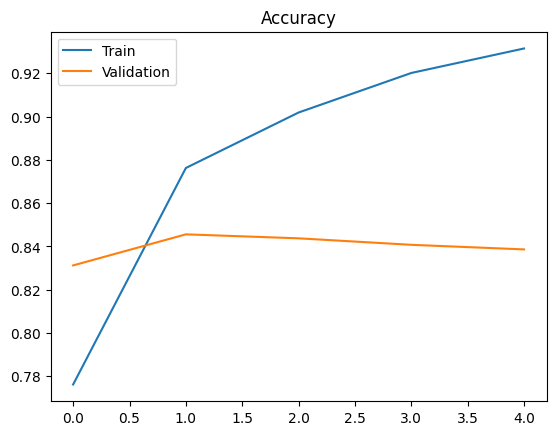

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [13]:
loss, acc = model.evaluate(x_test, y_test)

print("Final Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8386 - loss: 0.4059
Final Accuracy: 0.8385999798774719
